In [5]:
import os
import glob
import numpy as np
from matplotlib import pyplot as plt

def load_and_average_spectra(
    folder,
    pattern="*.txt",
    skip_header_lines=14,
    normalize="per_file",   # "per_file", "global", or "none"
    common_grid="auto",     # "auto", "first", or a 1D numpy array of wavelengths
    dtype=float
):
    """
    Load all spectra text files in `folder`, average them, and return (wavelengths, mean_intensity, std_intensity).

    File format assumptions:
      - Data start after `skip_header_lines` lines.
      - Each data line: "<wavelength> <intensity>" separated by whitespace.
    
    Parameters
    ----------
    folder : str
        Folder containing the spectra files.
    pattern : str, optional
        Glob pattern for files (default: "*.txt").
    skip_header_lines : int, optional
        Number of header lines to skip (default: 14).
    normalize : {"per_file","global","none"}, optional
        - "per_file": normalize each spectrum by its own max before averaging.
        - "global"  : normalize all intensities by the max over all files combined.
        - "none"    : no normalization.
    common_grid : {"auto","first", np.ndarray}, optional
        - "auto" : build a grid spanning the overlapping wavelength range and interpolate all files.
        - "first": use the first file's wavelength grid (interpolate others onto it).
        - np.ndarray: use this wavelength grid directly.
    dtype : type, optional
        Numpy dtype for parsed numbers.

    Returns
    -------
    wavelengths : np.ndarray
        The wavelength grid used for averaging.
    mean_intensity : np.ndarray
        The averaged intensity across files.
    std_intensity : np.ndarray
        The per-wavelength standard deviation across files.
    """
    files = sorted(glob.glob(os.path.join(folder, pattern)))
    if not files:
        raise FileNotFoundError(f"No files matching {pattern!r} found in {folder!r}")

    # Load all files
    spectra = []
    wl_lists = []
    raw_max = -np.inf

    for f in files:
        with open(f, "r") as fh:
            lines = fh.readlines()[skip_header_lines:]

        wl, it = [], []
        for line in lines:
            s = line.strip()
            if not s:
                continue
            parts = s.split()
            if len(parts) < 2:
                continue
            wl.append(dtype(parts[0]))
            it.append(dtype(parts[1]))
        wl = np.asarray(wl, dtype=float)
        it = np.asarray(it, dtype=float)

        if wl.size == 0 or it.size == 0:
            continue

        wl_lists.append(wl)
        spectra.append(it)
        raw_max = max(raw_max, np.max(it))

    if not spectra:
        raise ValueError("No valid spectra parsed from files.")

    # Choose / build a common wavelength grid
    if isinstance(common_grid, np.ndarray):
        grid = np.asarray(common_grid, dtype=float)
    elif common_grid == "first":
        grid = wl_lists[0]
    else:
        # auto: use overlapping min/max & a reasonable step based on median spacing
        # compute per-file spacing and use the median of medians
        mins = [w.min() for w in wl_lists]
        maxs = [w.max() for w in wl_lists]
        left = max(mins)
        right = min(maxs)
        if not np.isfinite(left) or not np.isfinite(right) or right <= left:
            raise ValueError("No overlapping wavelength range across files.")

        spacings = []
        for w in wl_lists:
            if len(w) > 1:
                spacings.append(np.median(np.diff(w)))
        step = np.median(spacings) if spacings else 1.0
        # Ensure positive, non-zero step
        step = float(step) if step > 0 else 1.0
        npts = int(np.floor((right - left) / step)) + 1
        grid = np.linspace(left, left + step*(npts-1), npts)

    # Interpolate each spectrum onto the common grid
    interp_specs = []
    for wl, it in zip(wl_lists, spectra):
        # np.interp extrapolates as edge values; better to clip to NaN then mask
        # but here we constructed grid to be within overlap; still, be safe:
        valid = (wl >= wl.min()) & (wl <= wl.max())
        if valid.sum() < 2:
            continue
        it_interp = np.interp(grid, wl[valid], it[valid])
        interp_specs.append(it_interp)

    if not interp_specs:
        raise ValueError("Interpolation produced no valid spectra (check grids / overlap).")

    interp_specs = np.vstack(interp_specs)  # shape: (n_files, n_points)

    # Normalization
    if normalize == "per_file":
        denom = np.max(interp_specs, axis=1, keepdims=True)
        denom[denom == 0] = 1.0
        interp_specs = interp_specs / denom
    elif normalize == "global":
        gmax = np.max(interp_specs) if np.isfinite(np.max(interp_specs)) else raw_max
        if gmax == 0 or not np.isfinite(gmax):
            gmax = 1.0
        interp_specs = interp_specs / gmax
    elif normalize == "none":
        pass
    else:
        raise ValueError("normalize must be 'per_file', 'global', or 'none'.")

    mean_intensity = np.nanmean(interp_specs, axis=0)
    std_intensity = np.nanstd(interp_specs, axis=0, ddof=1) if interp_specs.shape[0] > 1 else np.zeros_like(mean_intensity)

    return grid, mean_intensity, std_intensity


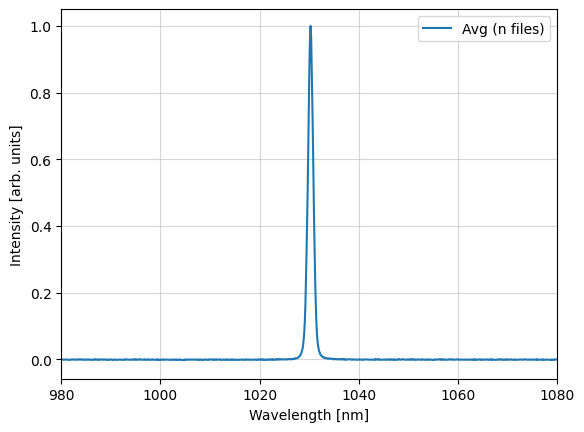

In [30]:
path = '250813_HC_spectra_August25/HC_spectra/1W/'

nm_1W, I_1W, std_1W = load_and_average_spectra(
    folder=path,
    pattern="*.txt",
    skip_header_lines=14,
    normalize="per_file",   # each file normalized before averaging (similar to your original)
    common_grid="first"     # align others to the first file's wavelength grid
)

# …later, when you’re ready to plot:
plt.plot(nm_1W, I_1W, label="Avg (n files)")
#plt.fill_between(wavelengths, avg_intensity-std_intensity, avg_intensity+std_intensity, alpha=0.2, label="±1σ")
plt.xlabel("Wavelength [nm]"); plt.ylabel("Intensity [arb. units]")
plt.xlim(980, 1080); plt.grid(True, alpha=0.5); plt.legend()


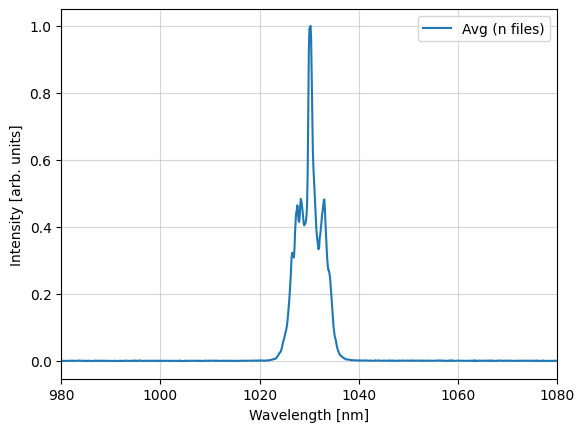

In [31]:
path = '250813_HC_spectra_August25/HC_spectra/10W/'

nm_10W, I_10W, std_10W = load_and_average_spectra(
    folder=path,
    pattern="*.txt",
    skip_header_lines=14,
    normalize="per_file",   # each file normalized before averaging (similar to your original)
    common_grid="first"     # align others to the first file's wavelength grid
)

# …later, when you’re ready to plot:
plt.plot(nm_10W, I_10W, label="Avg (n files)")
#plt.fill_between(wavelengths, avg_intensity-std_intensity, avg_intensity+std_intensity, alpha=0.2, label="±1σ")
plt.xlabel("Wavelength [nm]"); plt.ylabel("Intensity [arb. units]")
plt.xlim(980, 1080); plt.grid(True, alpha=0.5); plt.legend()


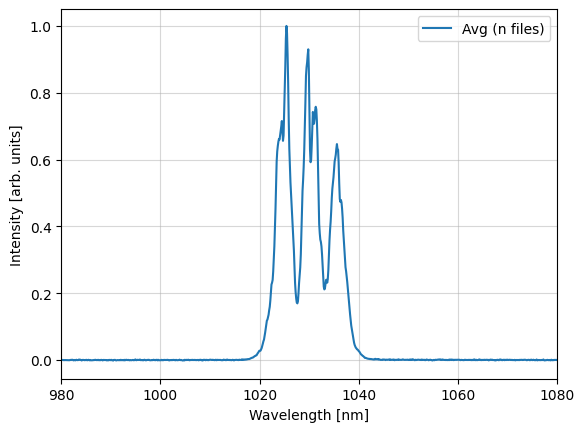

In [32]:
path = '250813_HC_spectra_August25/HC_spectra/20W/'

nm_20W, I_20W, std_20W = load_and_average_spectra(
    folder=path,
    pattern="*.txt",
    skip_header_lines=14,
    normalize="per_file",   # each file normalized before averaging (similar to your original)
    common_grid="first"     # align others to the first file's wavelength grid
)

# …later, when you’re ready to plot:
plt.plot(nm_20W, I_20W, label="Avg (n files)")
#plt.fill_between(wavelengths, avg_intensity-std_intensity, avg_intensity+std_intensity, alpha=0.2, label="±1σ")
plt.xlabel("Wavelength [nm]"); plt.ylabel("Intensity [arb. units]")
plt.xlim(980, 1080); plt.grid(True, alpha=0.5); plt.legend()


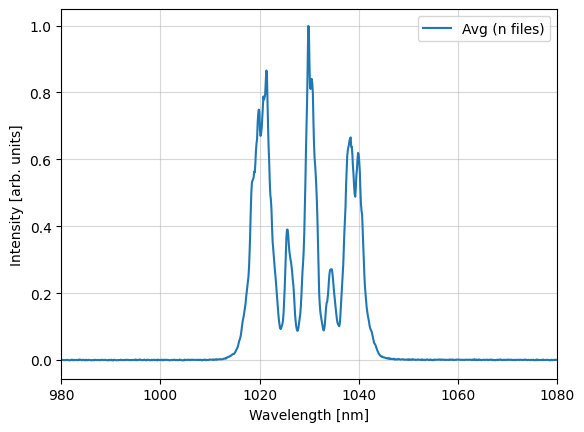

In [33]:
path = '250813_HC_spectra_August25/HC_spectra/30W/'

nm_30W, I_30W, std_30W = load_and_average_spectra(
    folder=path,
    pattern="*.txt",
    skip_header_lines=14,
    normalize="per_file",   # each file normalized before averaging (similar to your original)
    common_grid="first"     # align others to the first file's wavelength grid
)

# …later, when you’re ready to plot:
plt.plot(nm_30W, I_30W, label="Avg (n files)")
#plt.fill_between(wavelengths, avg_intensity-std_intensity, avg_intensity+std_intensity, alpha=0.2, label="±1σ")
plt.xlabel("Wavelength [nm]"); plt.ylabel("Intensity [arb. units]")
plt.xlim(980, 1080); plt.grid(True, alpha=0.5); plt.legend()


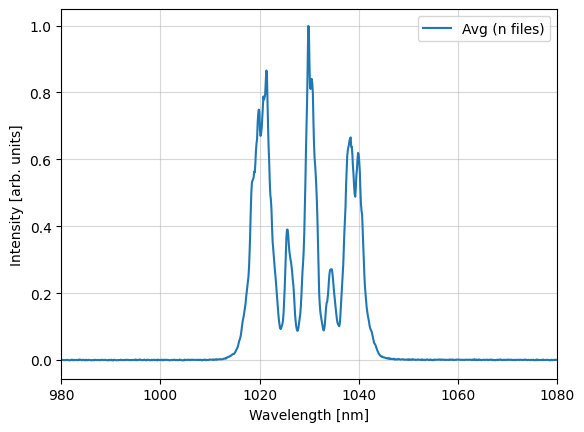

In [34]:
path = '250813_HC_spectra_August25/HC_spectra/30W/'

nm_30W, I_30W, std_30W = load_and_average_spectra(
    folder=path,
    pattern="*.txt",
    skip_header_lines=14,
    normalize="per_file",   # each file normalized before averaging (similar to your original)
    common_grid="first"     # align others to the first file's wavelength grid
)

# …later, when you’re ready to plot:
plt.plot(nm_30W, I_30W, label="Avg (n files)")
#plt.fill_between(wavelengths, avg_intensity-std_intensity, avg_intensity+std_intensity, alpha=0.2, label="±1σ")
plt.xlabel("Wavelength [nm]"); plt.ylabel("Intensity [arb. units]")
plt.xlim(980, 1080); plt.grid(True, alpha=0.5); plt.legend()


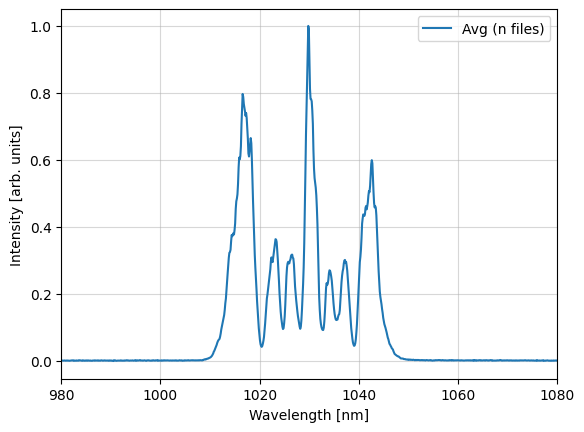

In [35]:
path = '250813_HC_spectra_August25/HC_spectra/40W/'

nm_40W, I_40W, std_40W = load_and_average_spectra(
    folder=path,
    pattern="*.txt",
    skip_header_lines=14,
    normalize="per_file",   # each file normalized before averaging (similar to your original)
    common_grid="first"     # align others to the first file's wavelength grid
)

# …later, when you’re ready to plot:
plt.plot(nm_40W, I_40W, label="Avg (n files)")
#plt.fill_between(wavelengths, avg_intensity-std_intensity, avg_intensity+std_intensity, alpha=0.2, label="±1σ")
plt.xlabel("Wavelength [nm]"); plt.ylabel("Intensity [arb. units]")
plt.xlim(980, 1080); plt.grid(True, alpha=0.5); plt.legend()


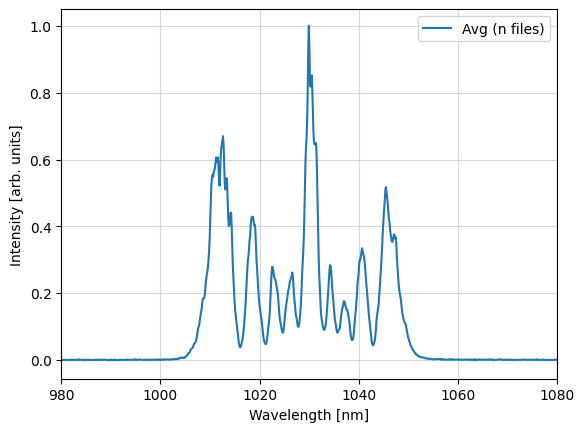

In [36]:
path = '250813_HC_spectra_August25/HC_spectra/50W/'

nm_50W, I_50W, std_50W = load_and_average_spectra(
    folder=path,
    pattern="*.txt",
    skip_header_lines=14,
    normalize="per_file",   # each file normalized before averaging (similar to your original)
    common_grid="first"     # align others to the first file's wavelength grid
)

# …later, when you’re ready to plot:
plt.plot(nm_50W, I_50W, label="Avg (n files)")
#plt.fill_between(wavelengths, avg_intensity-std_intensity, avg_intensity+std_intensity, alpha=0.2, label="±1σ")
plt.xlabel("Wavelength [nm]"); plt.ylabel("Intensity [arb. units]")
plt.xlim(980, 1080); plt.grid(True, alpha=0.5); plt.legend()


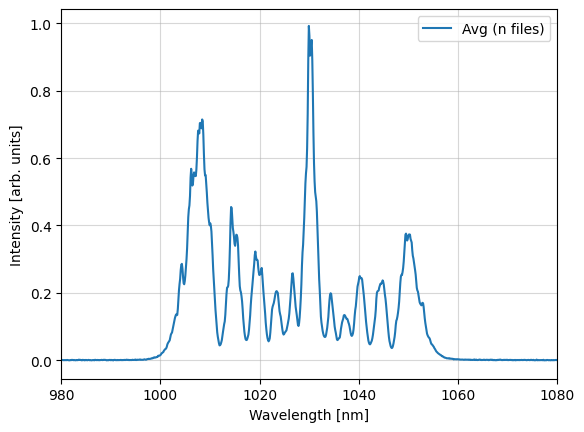

In [37]:
path = '250813_HC_spectra_August25/HC_spectra/60W/'

nm_60W, I_60W, std_60W = load_and_average_spectra(
    folder=path,
    pattern="*.txt",
    skip_header_lines=14,
    normalize="per_file",   # each file normalized before averaging (similar to your original)
    common_grid="first"     # align others to the first file's wavelength grid
)

# …later, when you’re ready to plot:
plt.plot(nm_60W, I_60W, label="Avg (n files)")
#plt.fill_between(wavelengths, avg_intensity-std_intensity, avg_intensity+std_intensity, alpha=0.2, label="±1σ")
plt.xlabel("Wavelength [nm]"); plt.ylabel("Intensity [arb. units]")
plt.xlim(980, 1080); plt.grid(True, alpha=0.5); plt.legend()


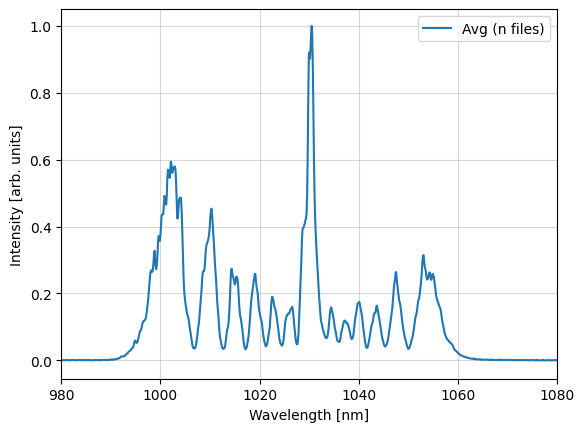

In [38]:
path = '250813_HC_spectra_August25/HC_spectra/70W/'

nm_70W, I_70W, std_70W = load_and_average_spectra(
    folder=path,
    pattern="*.txt",
    skip_header_lines=14,
    normalize="per_file",   # each file normalized before averaging (similar to your original)
    common_grid="first"     # align others to the first file's wavelength grid
)

# …later, when you’re ready to plot:
plt.plot(nm_70W, I_70W, label="Avg (n files)")
#plt.fill_between(wavelengths, avg_intensity-std_intensity, avg_intensity+std_intensity, alpha=0.2, label="±1σ")
plt.xlabel("Wavelength [nm]"); plt.ylabel("Intensity [arb. units]")
plt.xlim(980, 1080); plt.grid(True, alpha=0.5); plt.legend()


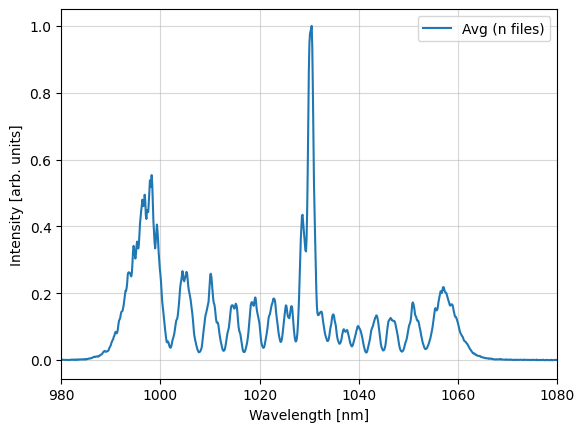

In [39]:
path = '250813_HC_spectra_August25/HC_spectra/80W/'

nm_80W, I_80W, std_80W = load_and_average_spectra(
    folder=path,
    pattern="*.txt",
    skip_header_lines=14,
    normalize="per_file",   # each file normalized before averaging (similar to your original)
    common_grid="first"     # align others to the first file's wavelength grid
)

# …later, when you’re ready to plot:
plt.plot(nm_80W, I_80W, label="Avg (n files)")
#plt.fill_between(wavelengths, avg_intensity-std_intensity, avg_intensity+std_intensity, alpha=0.2, label="±1σ")
plt.xlabel("Wavelength [nm]"); plt.ylabel("Intensity [arb. units]")
plt.xlim(980, 1080); plt.grid(True, alpha=0.5); plt.legend()


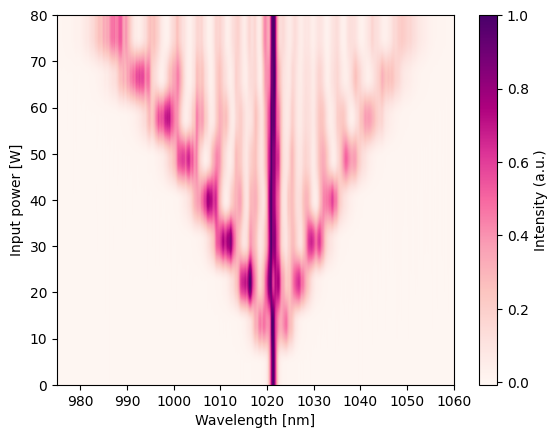

In [42]:
import matplotlib.pyplot as plt

SPM_grid = np.array([I_1W,I_10W,I_20W,I_30W,I_40W,I_50W,I_60W,I_70W,I_80W])
# Suppose your 2D grid is shape (ny, nx)
# and you know the axis ranges:
y_min, y_max = 0, 80         # maybe power, position, etc. (rows)

plt.imshow(
    SPM_grid,
    aspect='auto',
    extent=[nm_10W[0], nm_10W[-1], y_min, y_max],
    origin='lower',     # optional: makes y_min at the bottom
    cmap='RdPu'      # or any colormap you like
)

plt.xlabel("Wavelength [nm]")
plt.ylabel("Input power [W]")
plt.colorbar(label="Intensity (a.u.)")
plt.xlim(975,1060)
plt.show()


<>:81: SyntaxWarning: invalid escape sequence '\p'
<>:81: SyntaxWarning: invalid escape sequence '\p'
/var/folders/0_/nrrxny_x54j3w76q939n8pth0000gn/T/ipykernel_77738/3847373031.py:81: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(lam_nm_grid,I_lambda_sim*0.55,label=f"Simulated ($\\Delta \phi_{{NL}}$ = {B_value:.0f} rad)", lw=1, ls='dashed', color='red')


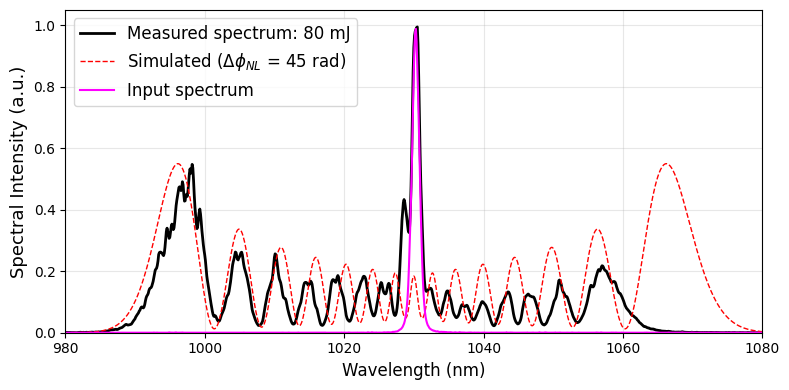

In [168]:
# === Overlay measured 80 W spectrum with simulated SPM (no fitting) ======
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants as sc
from scipy.fft import fft, fftfreq, fftshift

# ----------------- You set this -----------------
B_value    = 45.0          # <-- choose the SPM peak phase (rad) to simulate
lam0_nm    = 1030.0        # center wavelength (nm)
t_fwhm_ps  = 1.3           # pulse FWHM (ps)
lam_min_nm = 900.0         # plotting grid min/max & step
lam_max_nm = 1150.0
dlam_nm    = 0.1

# ----------------- Sampling for the simulation -----------------
T_window_ps = 200.0        # simulation time window (ps)
N = 2**18                  # number of samples (power of two is fast)

# ----------------- Derived quantities -----------------
lam0   = lam0_nm * 1e-9
omega0 = 2*np.pi*sc.c/lam0
t_fwhm = t_fwhm_ps * 1e-12
tau_sigma = t_fwhm/(2*np.sqrt(2*np.log(2)))   # Gaussian intensity σ

T_window = T_window_ps * 1e-12
dt = T_window / N
t  = (np.arange(N) - N//2) * dt

# Gaussian envelope (unit peak)
A_t = np.exp(-(t**2)/(2*tau_sigma**2))

# Build wavelength grid + omega(λ)
lam_nm_grid = np.arange(lam_min_nm, lam_max_nm + dlam_nm, dlam_nm)
lam = lam_nm_grid * 1e-9
omega_lam = 2*np.pi*sc.c/lam

def spectrum_vs_lambda(E_t):
    """Return normalized spectrum I(λ) on lam_nm_grid for a time-domain field E_t."""
    f = fftshift(fftfreq(N, d=dt))
    omega = 2*np.pi * f
    E_omega = fftshift(fft(np.fft.ifftshift(E_t))) * dt
    I_omega = np.abs(E_omega)**2

    # keep positive frequencies, normalize to max = 1
    pos = omega > 0
    omega_pos = omega[pos]
    I_pos = I_omega[pos]
    I_pos /= I_pos.max() if I_pos.max() != 0 else 1.0

    # map to wavelength axis
    idx = np.argsort(omega_pos)
    I_lambda = np.interp(omega_lam, omega_pos[idx], I_pos[idx], left=0.0, right=0.0)
    return I_lambda

def simulated_spectrum_for_B(B):
    """SPM-only phase with Gaussian profile φ(t) = B * exp(-t^2/σ^2)."""
    phi_spm = B * np.exp(-(t**2)/(tau_sigma**2))
    E_t = A_t * np.exp(1j*phi_spm) * np.exp(1j*omega0*t)
    return spectrum_vs_lambda(E_t)

# ----------------- Measured data (from your heatmap) -----------------
# Assumes you already have:
#   SPM_grid: np.array([I_1W, I_10W, ..., I_80W])  shape = (9, n_lambda)
#   nm_10W:   wavelength axis (nm) for those spectra
exp_lam_nm = nm_10W
exp_80W    = np.asarray(SPM_grid[-1], dtype=float)
exp_80W = np.clip(exp_80W, 0, None)
exp_80W /= exp_80W.max() if exp_80W.max() > 0 else 1.0
exp_on_sim = np.interp(lam_nm_grid, exp_lam_nm, exp_80W, left=0.0, right=0.0)

exp_1W    = np.asarray(SPM_grid[0], dtype=float)
exp_1W = np.clip(exp_1W, 0, None)
exp_1W /= exp_1W.max() if exp_1W.max() > 0 else 1.0
exp_on_sim_1W = np.interp(lam_nm_grid, exp_lam_nm, exp_1W, left=0.0, right=0.0)

# ----------------- Simulate and plot overlay -----------------
I_lambda_sim = simulated_spectrum_for_B(B_value)

plt.figure(figsize=(8,4))
plt.plot(lam_nm_grid, exp_on_sim,     label="Measured spectrum: 80 mJ", lw=2,color='black')
plt.plot(lam_nm_grid,I_lambda_sim*0.55,label=f"Simulated ($\\Delta \phi_{{NL}}$ = {B_value:.0f} rad)", lw=1, ls='dashed', color='red')
plt.plot(lam_nm_grid, exp_on_sim_1W,color='magenta',label='Input spectrum')
plt.xlabel("Wavelength (nm)",size=12)
plt.ylabel("Spectral Intensity (a.u.)",size=13)
#plt.title("Measured 80 W vs. SPM Simulation")
plt.xlim(1030-50, 1030+50)  # adjust as you like
plt.grid(True, alpha=0.3)
plt.ylim(0,1.05)
plt.legend(loc='upper left',prop={'size': 12})
plt.tight_layout()
plt.show()


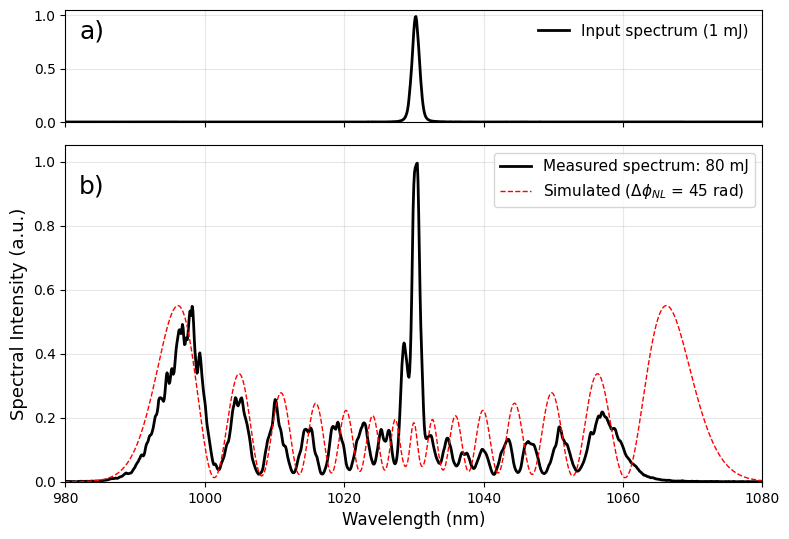

In [182]:
# ----------------- Simulate -----------------
I_lambda_sim = simulated_spectrum_for_B(B_value)

# ----------------- Plot in two stacked panels -----------------
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, figsize=(8,5.5),
    sharex=True,
    gridspec_kw={"height_ratios":[1,3]}  # top shorter, bottom taller
)

# --- top: input spectrum only ---
ax_top.plot(lam_nm_grid, exp_on_sim_1W, color='black', lw=2, label="Input spectrum (1 mJ)")
#ax_top.set_ylabel("Input\n(norm.)", fontsize=11)
ax_top.legend(loc="upper right", fontsize=11, frameon=False)
ax_top.set_ylim(0, 1.05)
ax_top.grid(True, alpha=0.3)

# --- bottom: measured vs simulated broadened ---
ax_bottom.plot(lam_nm_grid, exp_on_sim, label="Measured spectrum: 80 mJ", lw=2, color='black')
ax_bottom.plot(lam_nm_grid, I_lambda_sim*0.55,
               label=f"Simulated ($\\Delta \\phi_{{NL}}$ = {B_value:.0f} rad)",
               lw=1, ls='dashed', color='red')
ax_bottom.set_xlabel("Wavelength (nm)", fontsize=12)
ax_bottom.set_ylabel("Spectral Intensity (a.u.)", fontsize=13)
ax_bottom.set_xlim(1030-50, 1030+50)
ax_bottom.set_ylim(0, 1.05)
ax_bottom.legend(loc='upper right', fontsize=11)
ax_bottom.grid(True, alpha=0.3)

ax_top.text(s='a)',x=982,y=0.78,size=18)
ax_bottom.text(s='b)',x=982,y=0.90,size=18)

plt.tight_layout()
plt.show()


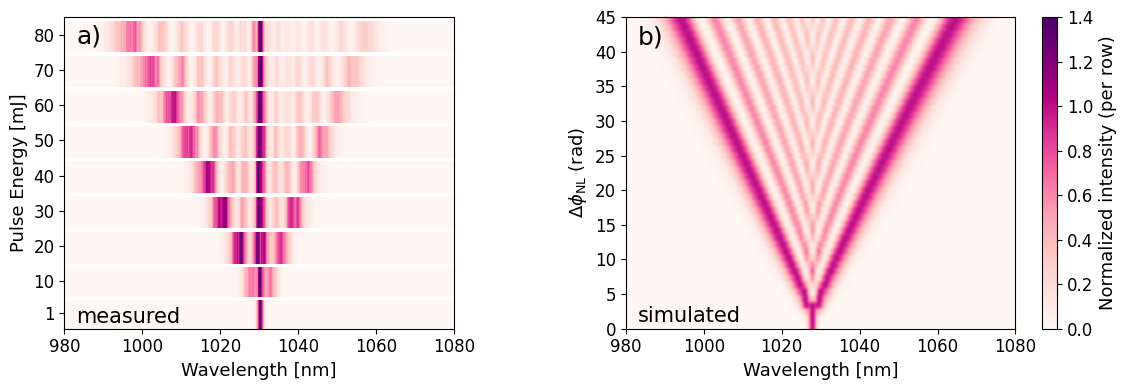

In [197]:
# === Measured map with true gaps (aligned to power) + robust SPM-only sim ===
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants as sc
from scipy.fft import fft, fftfreq, fftshift, ifftshift

# ------------------------------------------------------------------------
# Provide your measured data here (as before):
#   SPM_grid = np.array([I_1W, I_10W, I_20W, I_30W, I_40W, I_50W, I_60W, I_70W, I_80W])
#   nm_10W   = wavelength axis (nm) for those spectra
# ------------------------------------------------------------------------

# -------------------- view window --------------------
lam_min_nm, lam_max_nm = 1030-100, 1030+100

# -------------------- measured powers ----------------
power_meas = np.array([1, 10, 20, 30, 40, 50, 60, 70, 80], dtype=float)

# -------------------- rendering knobs ----------------
row_normalize_meas = True     # normalize each measured spectrum row to its own max
gap_fraction       = 0.10     # fraction of each power bin shown as blank gap
gap_color          = 'white'  # color of those gaps

# -------------------- synthetic map knobs (SPM ONLY) ----------------
lam0_nm   = 1030.0     # center wavelength (nm)
t_fwhm_ps = 1.3        # pulse FWHM (ps)
B_min, B_max, n_B = 0.0, 45.0, 46  # B axis (rad)
# time grid (kept modest for speed but accurate enough)
sigma_t_ps  = t_fwhm_ps/(2*np.sqrt(2*np.log(2)))   # intensity σ (ps)
T_window_ps = 12 * sigma_t_ps                       # ~±6σ
N           = 2**15                                 # 32768 samples

# -------------------- measured map prep ----------------
# interpolate each measured row to a common λ grid and crop to window
lam_nm_grid_full = nm_10W.copy()
sel = (lam_nm_grid_full >= lam_min_nm) & (lam_nm_grid_full <= lam_max_nm)
lam_nm_plot = lam_nm_grid_full[sel]

SPM_meas_interp = np.array([
    np.interp(lam_nm_plot, nm_10W, np.clip(row, 0, None), left=0.0, right=0.0)
    for row in SPM_grid
])
if row_normalize_meas:
    m = SPM_meas_interp.max(axis=1, keepdims=True)
    m[m == 0] = 1.0
    SPM_meas_interp = SPM_meas_interp / m

# build power-bin edges and insert true gaps
def power_bin_edges(p):
    p = np.asarray(p, float)
    mids = (p[1:] + p[:-1]) / 2
    e0 = p[0] - (mids[0] - p[0])
    eN = p[-1] + (p[-1] - mids[-1])
    return np.concatenate(([e0], mids, [eN]))

edges = power_bin_edges(power_meas)         # length Np+1
bin_heights = np.diff(edges)                # Np
gap_sizes = gap_fraction * bin_heights
data_tops = edges[1:] - gap_sizes

# Y-edges for pcolormesh: alternate data strip then gap per row
Y_edges = np.empty(2*len(power_meas) + 1, dtype=float)
Y_edges[0] = edges[0]
for i in range(len(power_meas)):
    Y_edges[2*i + 1] = data_tops[i]  # top of data strip
    Y_edges[2*i + 2] = edges[i+1]    # end of gap (= next edge)

# Z with interleaved data rows and NaN gaps
Z_meas = np.empty((2*len(power_meas), SPM_meas_interp.shape[1]), dtype=float)
Z_meas[0::2, :] = SPM_meas_interp
Z_meas[1::2, :] = np.nan

# X-edges for pcolormesh
def cell_edges(v):
    v = np.asarray(v)
    mid = (v[1:] + v[:-1]) / 2
    return np.concatenate(([v[0] - (mid[0] - v[0])], mid, [v[-1] + (v[-1] - mid[-1])]))

X_edges = cell_edges(lam_nm_plot)

# -------------------- synthetic SPM-only (complex FFT, robust) ------------
lam0   = lam0_nm * 1e-9
omega0 = 2*np.pi*sc.c/lam0

T_window = T_window_ps * 1e-12
dt = T_window / N
t  = (np.arange(N) - N//2) * dt

# time-domain Gaussian envelope and SPM phase shape
sigma_t = sigma_t_ps * 1e-12
A_t = np.exp(-(t**2)/(2*sigma_t**2))
g_t = np.exp(-(t**2)/(sigma_t**2))   # φ_SPM(t) = B * g_t

# frequency grid for complex FFT
f = fftshift(fftfreq(N, d=dt))       # Hz
Omega = 2*np.pi * f                  # rad/s (absolute, because we include carrier)

# λ→ω mapping for our plot window (absolute ω)
omega_lam = 2*np.pi*sc.c/(lam_nm_plot*1e-9)

def spectrum_vs_lambda(E_t):
    """Normalized spectrum on lam_nm_plot via complex FFT (robust)."""
    E_omega = fftshift(fft(ifftshift(E_t))) * dt
    I_omega = np.abs(E_omega)**2
    pos = Omega > 0
    omega_pos = Omega[pos]
    I_pos = I_omega[pos]
    # interpolate to ω(λ) and normalize in λ space
    idx = np.argsort(omega_pos)
    I_lambda = np.interp(omega_lam, omega_pos[idx], I_pos[idx], left=0.0, right=0.0)
    mx = I_lambda.max()
    if mx > 0:
        I_lambda /= mx
    return I_lambda

def simulate_spectrum_for_B(B_value):
    E_t = A_t * np.exp(1j * (B_value * g_t)) * np.exp(1j*omega0*t)
    return spectrum_vs_lambda(E_t)

B_list = np.linspace(B_min, B_max, n_B)
synthetic_map = np.vstack([simulate_spectrum_for_B(B) for B in B_list])

# -------------------- plot both panels ------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=False)

# (a) measured with thin gaps, rows aligned to power values
Xg, Yg = np.meshgrid(X_edges, Y_edges)
cmap = plt.cm.RdPu.copy()
cmap.set_bad(gap_color, 1.0)
mesh0 = axs[0].pcolormesh(Xg, Yg, Z_meas, shading='flat', cmap=cmap, vmin=0.0, vmax=1)
axs[0].set_ylim(Y_edges[0], Y_edges[-1])
axs[0].set_xlim(1030-40, 1030+40)
axs[0].set_xlabel("Wavelength [nm]", fontsize=13)
axs[0].set_ylabel("Pulse Energy [mJ]", fontsize=13)
axs[0].set_yticks(power_meas)
axs[0].tick_params(axis='both', which='major', labelsize=12)

# (b) synthetic SPM-only map (B on y)
im1 = axs[1].imshow(
    synthetic_map, aspect='auto',
    extent=[lam_nm_plot[0], lam_nm_plot[-1], B_min, B_max],
    origin='lower', cmap='RdPu', vmin=0.0, vmax=1.4
)
axs[1].set_xlim(1030-40, 1030+40)
axs[1].set_xlabel("Wavelength [nm]", fontsize=13)
axs[1].set_ylabel(r"$\Delta \phi_\text{NL}$ (rad)", fontsize=13)
axs[1].tick_params(axis='both', which='major', labelsize=12)

# enforce same aspect ratio for both subplots
for ax in axs:
    dx = np.diff(ax.get_xlim())[0]
    dy = np.diff(ax.get_ylim())[0]
    ax.set_aspect(dx/dy)

# colorbar
cbar = fig.colorbar(im1, ax=axs[1])
cbar.set_label("Normalized intensity (per row)", fontsize=13)
cbar.ax.tick_params(labelsize=12)


h_over_w = 0.8   # try 0.8–1.2 depending on taste
for ax in axs:
    ax.set_box_aspect(h_over_w)

axs[0].text(s='a)',x=983,y=77.5,size=18)
axs[1].text(s='b)',x=983,y=41,size=18)

axs[0].text(s='measured',x=983,y=-2,size=15)
axs[1].text(s='simulated',x=983,y=1,size=15)

plt.tight_layout()


